In [1]:
import pandas as pd
import matplotlib.colors as mcolors
import colorsys
import itertools
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
outdoor_hum = pd.read_csv('./campaign_data/outdoor_hum.csv')

# Convert 'Date/Time' to datetime format
outdoor_hum['Date/Time'] = pd.to_datetime(outdoor_hum['Date/Time'])

# Set 'Date/Time' as the index
outdoor_hum.set_index('Date/Time', inplace=True)

/tmp/ipykernel_6804/1742313865.py:1: DtypeWarning: Columns (11) have mixed types. Specify dtype option on import or set low_memory=False.
  outdoor_hum = pd.read_csv('./campaign_data/outdoor_hum.csv')


In [3]:
site_type = {'AD': ['Asylum Down', 'Commercial/\nbusiness/\nindustrial','blue'],
             'ASH' : ['Ashaiman', 'Medium/low-density\nresidential', 'tab:orange'],
             'EL': ['East Legon', 'Medium/low-density\nresidential', 'tab:orange'],
             'JT' : ['James Town', 'High-density\nresidential', 'red'],
             'LA': ['Labadi', 'Medium/low-density\nresidential', 'tab:orange'],
             'N1W': ['N1 West Motorway', 'Commercial/\nbusiness/\nindustrial','blue'],
             'NM': ['Nima', 'High-density\nresidential', 'red'],
             'TF': ['Taifa','Medium/low-density\nresidential', 'tab:orange'],
             'TMW': ['Tema Motorway', 'Commercial/\nbusiness/\nindustrial','blue'],
             'UGH': ['University of Ghana', 'Peri-urban background', 'green']}

In [5]:
# Group by 'sensor_id' and calculate the number of unique 'site_id's for each 'sensor_id'
unique_site_ids_per_sensor = outdoor_hum.groupby('sensor_id_outdoor_hum')['site_id'].nunique()

# Check if any 'sensor_id' is associated with more than one 'site_id'
multiple_sites_per_sensor = unique_site_ids_per_sensor[unique_site_ids_per_sensor > 1]

if len(multiple_sites_per_sensor) > 0:
    print("These sensor_ids are associated with multiple site_ids:")
    print(multiple_sites_per_sensor)
else:
    print("Every sensor_id is associated with a unique site_id.")


Every sensor_id is associated with a unique site_id.


In [8]:
outdoor_hum_hourly = outdoor_hum.groupby('sensor_id_outdoor_hum').resample('H').mean(numeric_only=True)

# Reset the index
outdoor_hum_hourly.reset_index(inplace=True)

# Pivot the data so that each sensor has its own column
outdoor_hum_pivot = outdoor_hum_hourly.pivot(index='Date/Time', columns='sensor_id_outdoor_hum', values='Value')

# Compute the correlation between each pair of sensors
correlations = outdoor_hum_pivot.corr()

print(correlations)

sensor_id_outdoor_hum    '91BB'    '92FC'    '9336'    '9438'    '9463'  \
sensor_id_outdoor_hum                                                     
'91BB'                 1.000000  0.933964  0.864113  0.843810  0.854448   
'92FC'                 0.933964  1.000000  0.843919  0.839935  0.905432   
'9336'                 0.864113  0.843919  1.000000  0.927085  0.867374   
'9438'                 0.843810  0.839935  0.927085  1.000000  0.892093   
'9463'                 0.854448  0.905432  0.867374  0.892093  1.000000   
'94DE'                 0.854159  0.881340  0.916057  0.919524  0.940986   
'950F'                 0.844966  0.883761  0.875505  0.912301  0.908049   
'9670'                 0.905816  0.945508  0.868043  0.886039  0.947748   
'9887'                 0.783857  0.858778  0.939232  0.893916  0.843889   
'9A9A'                 0.866880  0.877242  0.944945  0.953122  0.923280   
'9D7B'                 0.744857  0.938724       NaN  0.842313  0.954700   
'A1A2'                 0.

In [9]:
# Function to convert colormap
def convert_blue_to_green(cmap):
    cmap = plt.get_cmap(cmap)
    colors_rgb = cmap(np.arange(cmap.N))

    # Convert RGB to HLS
    colors_hls = np.array([colorsys.rgb_to_hls(*color_rgb) for color_rgb in colors_rgb[:, :3]])

    # Change hue from blue to green (240 degrees to 120 degrees)
    colors_hls[:, 0] = (colors_hls[:, 0] - 2 / 3) % 1

    # Convert back to RGB
    colors_rgb = np.array([colorsys.hls_to_rgb(*color_hls) for color_hls in colors_hls])

    # Create new colormap
    new_cmap = mcolors.LinearSegmentedColormap.from_list("green_seismic", colors_rgb, cmap.N)

    return new_cmap

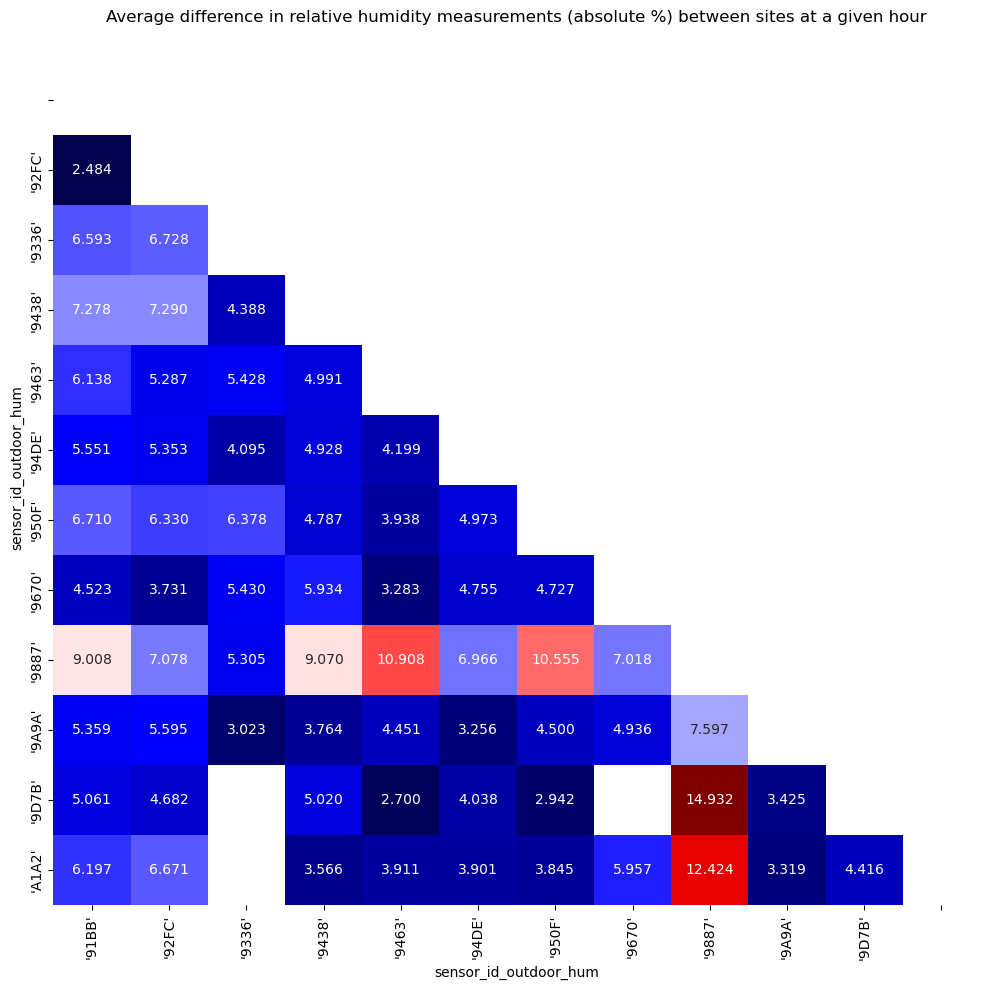

In [10]:
# Create a new dataframe where each site's hourly readings are separate columns
outdoor_hum_hourly = outdoor_hum.groupby('sensor_id_outdoor_hum').resample('H').mean(numeric_only=True).unstack(level=0)['Value']

# Initialize a new dataframe to store the differences
diffs = pd.DataFrame(index=outdoor_hum_hourly.columns, columns=outdoor_hum_hourly.columns)

# Calculate the average absolute difference for each pair of sites
for site1, site2 in itertools.combinations(outdoor_hum_hourly.columns, 2):
    diffs.loc[site1, site2] = diffs.loc[site2, site1] = np.mean(np.abs(outdoor_hum_hourly[site1] - outdoor_hum_hourly[site2]))

# Convert the differences dataframe to float
diffs = diffs.astype(float)

# Assume the site names are 'site 1', 'site 2', etc.
site_names = diffs.columns

labelling = {name: name for name in site_names}

# Rename the columns and index of the differences dataframe for display
diffs.rename(columns=labelling, index=labelling, inplace=True)

# Create a mask to hide the upper triangle of the correlation matrix, since it's symmetric
mask = np.triu(np.ones_like(diffs, dtype=bool))

for i in range(len(mask)):
    mask[i,i] = False

# Plot size
fig, ax = plt.subplots(figsize=(10,10))

# Format the difference values to 3 decimal places for display
labels = (np.asarray(["{:.3f}".format(data) for data in diffs.to_numpy().flatten()])).reshape(len(site_names),len(site_names))

# Your function to create a new colormap
# new_cmap = convert_blue_to_green('seismic')

# Plot the difference matrix
# diff_plot = sns.heatmap(diffs.astype(float), annot=labels, fmt='', cmap=plt.get_cmap(new_cmap), vmin=0, vmax=100, cbar=False, ax=ax, mask=mask)
diff_plot = sns.heatmap(diffs.astype(float), annot=labels, fmt='', cmap='seismic', cbar=False, ax=ax, mask=mask)

# Fix for the matplotlib bug that cuts off half of the top and bottom cells
b, t = plt.ylim()
t -= 0.5
plt.ylim(b, t)

plt.title('Average difference in relative humidity measurements (absolute %) between sites at a given hour')

plt.xticks(rotation=90)

# Get the original labels
ylabels = [item.get_text() for item in ax.get_yticklabels()]
xlabels = [item.get_text() for item in ax.get_xticklabels()]

# Replace the first ylabel and the last xlabel with an empty string
ylabels[0] = ''
xlabels[-1] = ''

# Set the new labels
ax.set_yticklabels(ylabels)
ax.set_xticklabels(xlabels, rotation=90)

plt.tight_layout()
plt.savefig('paper_plots/humidity_difference_plot.png', facecolor='white')

In [17]:
half_hourly = outdoor_hum.groupby('sensor_id_outdoor_hum').resample('30T').mean(numeric_only=True)

# Now, unstack the 'site_id' level of the MultiIndex so we have one column per site
half_hourly = half_hourly.unstack(level=0)['Value']

# Calculate the mean across all sites for each half-hour
citywide_humidity = half_hourly.mean(axis=1)

# Calculate the 2.5th and 97.5th percentiles across all sites for each half-hour
percentile_2_5 = half_hourly.quantile(0.025, axis=1)
percentile_97_5 = half_hourly.quantile(0.975, axis=1)

# Calculate the difference between the 97.5th and 2.5th percentiles
range_2_5_to_97_5 = percentile_97_5 - percentile_2_5

# Combine these into a single dataframe
citywide_humidity_df = pd.DataFrame({
    'Average Humidity': citywide_humidity,
    '95_Range': range_2_5_to_97_5
})

# Print the resulting dataframe
print(citywide_humidity_df)


                     Average Humidity   95_Range
Date/Time                                       
2022-08-05 08:00:00         65.182000   0.000000
2022-08-05 08:30:00         71.246333   0.000000
2022-08-05 09:00:00         67.588167   0.421483
2022-08-05 09:30:00         65.285889   4.048267
2022-08-05 10:00:00         65.642333  14.049867
...                               ...        ...
2023-09-25 09:00:00         96.413333  11.048817
2023-09-25 09:30:00         95.443444  10.387300
2023-09-25 10:00:00         91.007833   2.362650
2023-09-25 10:30:00         87.896667   0.363533
2023-09-25 11:00:00         85.983000   0.000000

[19975 rows x 2 columns]


<Axes: >

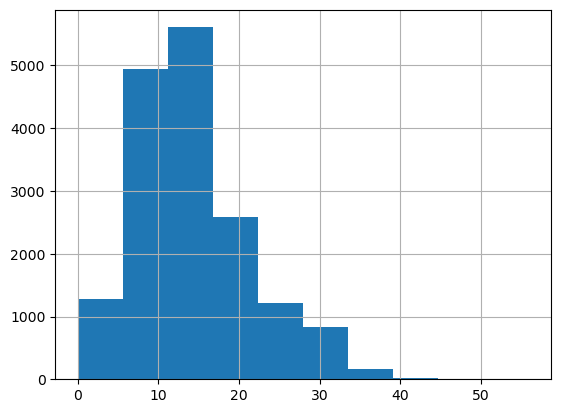

In [21]:
citywide_humidity_df['95_Range'].hist()

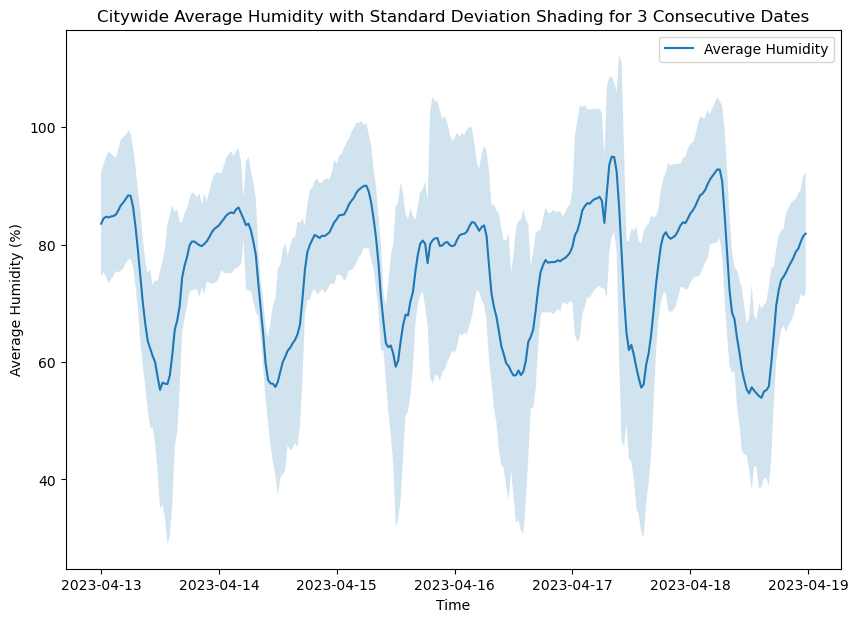

In [18]:
import matplotlib.pyplot as plt
import random

# Find a random start day (ignoring the last 3 days to allow for three consecutive days)
start_day = random.choice(citywide_humidity_df.index[:-3].date)

# Select three consecutive days using the date directly in the slicing
selected_data = citywide_humidity_df[str(start_day):str(start_day + pd.Timedelta(days=5))]

# Initialize a figure
fig, ax = plt.subplots(figsize=(10, 7))

# Plot the average humidity
ax.plot(selected_data.index, selected_data['Average Humidity'], label='Average Humidity')

# Plot the standard deviation as shaded area
ax.fill_between(selected_data.index, 
                (selected_data['Average Humidity'] - selected_data['95_Range']), 
                (selected_data['Average Humidity'] + selected_data['95_Range']), 
                alpha=0.2)

# Set the title, labels, and legend
ax.set_title('Citywide Average Humidity with Standard Deviation Shading for 3 Consecutive Dates')
ax.set_xlabel('Time')
ax.set_ylabel('Average Humidity (%)')
ax.legend()

plt.show()


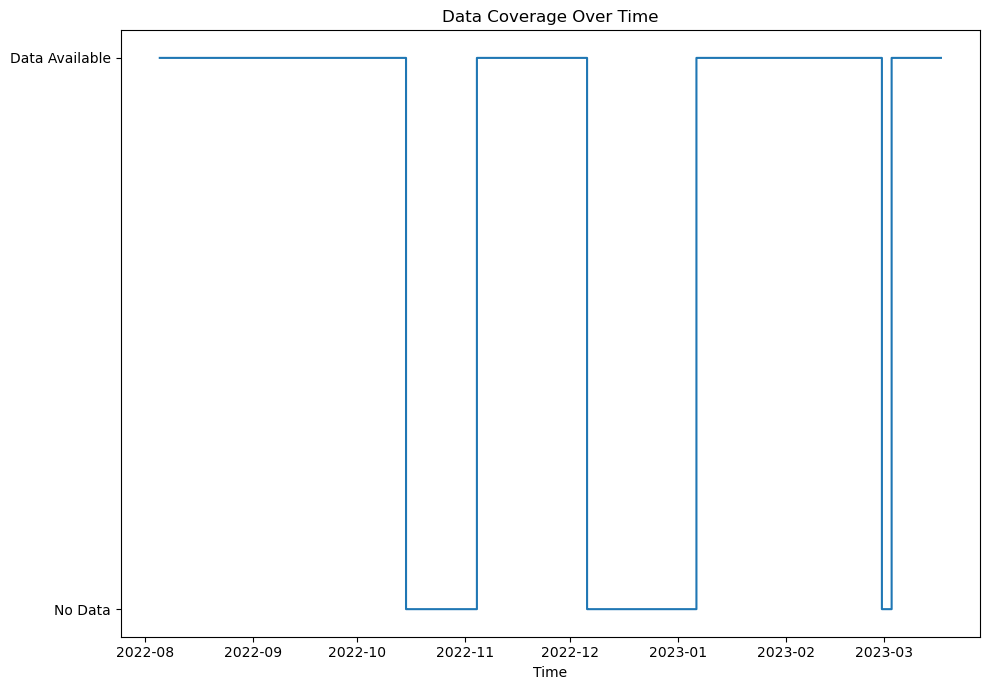

In [19]:
import matplotlib.pyplot as plt

# Create a binary series where 1 indicates that data is available and 0 indicates that it is not
coverage = citywide_humidity_df['Average Humidity'].notna().astype(int)

# Initialize a figure
fig, ax = plt.subplots(figsize=(10, 7))

# Plot the data coverage
ax.plot(coverage.index, coverage, drawstyle='steps-post')

# Set the y-axis labels
ax.set_yticks([0, 1])
ax.set_yticklabels(['No Data', 'Data Available'])

# Set the title and labels
ax.set_title('Data Coverage Over Time')
ax.set_xlabel('Time')

plt.tight_layout()
plt.show()


In [22]:
citywide_humidity_df.to_csv('accra_humidity.csv')

In [43]:
indoor_hum.Lat.unique()

array([5.73477, 5.54096, 5.54001, 5.59537, 5.69395, 5.60283, 5.56195,
       5.55971, 5.59128, 5.65752, 5.65061])